# Problem 2 (6 pkt) - ciagla przestrzen obserwacji
### CartPole-v1 + Q-Learning z dyskretyzacja
Notebook przepisany od zera, z opcja kontynuacji treningu.
Przy gamma=0.9 raportujemy dwa progi sukcesu: >=475 (surowy) oraz >=200 (praktyczny).

In [20]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time

ENV_NAME = "CartPole-v1"
TRAIN_EPISODES = 15000
EXTRA_EPISODES = 10000
MAX_STEPS = 500
ALPHA = 0.12
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_MIN = 0.02
BINS = (8, 10, 16, 16)
EVAL_WINDOW = 100
SEED = 42
N_EVAL = 500
SUCCESS_THRESHOLD_STRICT = 475
SUCCESS_THRESHOLD_PRACTICAL = 200
TOTAL_EPISODES = TRAIN_EPISODES + EXTRA_EPISODES

print(f"gymnasium version: {gym.__version__}")
print(f"numpy version:     {np.__version__}")
print("")
print("Hiperparametry:")
print(f"  TRAIN_EPISODES:          {TRAIN_EPISODES}")
print(f"  EXTRA_EPISODES:          {EXTRA_EPISODES}")
print(f"  alpha:                   {ALPHA}")
print(f"  gamma:                   {GAMMA}")
print(f"  epsilon:                 {EPSILON_START} -> {EPSILON_MIN} (liniowy harmonogram)")
print(f"  bins:                    {BINS}")
print(f"  sukces surowy prog:      >={SUCCESS_THRESHOLD_STRICT}")
print(f"  sukces praktyczny prog:  >={SUCCESS_THRESHOLD_PRACTICAL}")

gymnasium version: 1.2.3
numpy version:     2.4.2

Hiperparametry:
  TRAIN_EPISODES:          15000
  EXTRA_EPISODES:          10000
  alpha:                   0.12
  gamma:                   0.99
  epsilon:                 1.0 -> 0.02 (liniowy harmonogram)
  bins:                    (8, 10, 16, 16)
  sukces surowy prog:      >=475
  sukces praktyczny prog:  >=200


In [21]:
env_info = gym.make(ENV_NAME)
print(f"Observation space: {env_info.observation_space}")
print(f"Action space:      {env_info.action_space}")
print("low: ", env_info.observation_space.low)
print("high:", env_info.observation_space.high)
env_info.close()

# Niejednorodne koszyki (bin edges) - wieksza rozdzielczosc blisko 0.
# Cart position
X_BINS = np.linspace(-2.4, 2.4, BINS[0] - 1, dtype=np.float32)
# Cart velocity
X_DOT_BINS = np.linspace(-2.5, 2.5, BINS[1] - 1, dtype=np.float32)
# Pole angle (najwazniejsza zmienna)
THETA_BINS = np.linspace(-0.2095, 0.2095, BINS[2] - 1, dtype=np.float32)
# Pole angular velocity
THETA_DOT_BINS = np.linspace(-2.8, 2.8, BINS[3] - 1, dtype=np.float32)

env_tmp = gym.make(ENV_NAME)
N_ACTIONS = int(env_tmp.action_space.n)
env_tmp.close()

def discretize_state(state):
    x, x_dot, theta, theta_dot = np.asarray(state, dtype=np.float32)
    idx0 = int(np.digitize(x, X_BINS))
    idx1 = int(np.digitize(x_dot, X_DOT_BINS))
    idx2 = int(np.digitize(theta, THETA_BINS))
    idx3 = int(np.digitize(theta_dot, THETA_DOT_BINS))
    idx0 = np.clip(idx0, 0, BINS[0] - 1)
    idx1 = np.clip(idx1, 0, BINS[1] - 1)
    idx2 = np.clip(idx2, 0, BINS[2] - 1)
    idx3 = np.clip(idx3, 0, BINS[3] - 1)
    return (idx0, idx1, idx2, idx3)

print(f"Liczba akcji: {N_ACTIONS}")
print(f"Test dyskretyzacji [0,0,0,0]: {discretize_state([0,0,0,0])}")

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:      Discrete(2)
low:  [-4.8               -inf -0.41887903        -inf]
high: [4.8               inf 0.41887903        inf]
Liczba akcji: 2
Test dyskretyzacji [0,0,0,0]: (np.int64(4), np.int64(5), np.int64(8), np.int64(8))


In [22]:
def greedy_action(q_table, state_idx, rng):
    q_vals = q_table[state_idx]
    best_actions = np.flatnonzero(q_vals == np.max(q_vals))
    return int(rng.choice(best_actions))

def epsilon_by_episode(global_ep):
    frac = min(1.0, max(0.0, global_ep / float(TOTAL_EPISODES)))
    return EPSILON_START + frac * (EPSILON_MIN - EPSILON_START)

def train_q_learning(q_table, episodes, epsilon, start_episode_idx=0, log_every=500):
    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(SEED + start_episode_idx)

    rewards = []
    lengths = []
    strict_successes = []
    practical_successes = []

    best_q = q_table.copy()
    best_score = -np.inf
    best_episode = start_episode_idx

    for local_ep in range(episodes):
        global_ep = start_episode_idx + local_ep + 1
        epsilon = epsilon_by_episode(global_ep)

        state, _ = env.reset(seed=SEED + start_episode_idx + local_ep)
        state_idx = discretize_state(state)
        total_reward = 0.0

        for step in range(MAX_STEPS):
            if rng.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = greedy_action(q_table, state_idx, rng)

            next_state, reward, terminated, truncated, _ = env.step(action)
            next_idx = discretize_state(next_state)
            done = terminated or truncated

            best_next = 0.0 if done else float(np.max(q_table[next_idx]))
            td_target = reward + GAMMA * best_next
            td_error = td_target - q_table[state_idx + (action,)]
            q_table[state_idx + (action,)] += ALPHA * td_error

            state_idx = next_idx
            total_reward += float(reward)

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        strict_successes.append(1 if total_reward >= SUCCESS_THRESHOLD_STRICT else 0)
        practical_successes.append(1 if total_reward >= SUCCESS_THRESHOLD_PRACTICAL else 0)

        if global_ep % log_every == 0:
            avg_reward = float(np.mean(rewards[-log_every:]))
            avg_strict = float(np.mean(strict_successes[-log_every:]) * 100)
            avg_practical = float(np.mean(practical_successes[-log_every:]) * 100)
            score = avg_practical + 0.01 * avg_reward

            if score > best_score:
                best_score = score
                best_q = q_table.copy()
                best_episode = global_ep

            print(
                f"Epizod {global_ep:5d} | eps={epsilon:.3f} | avg reward: {avg_reward:7.2f} | sukces >={SUCCESS_THRESHOLD_STRICT}: {avg_strict:5.1f}% | sukces >={SUCCESS_THRESHOLD_PRACTICAL}: {avg_practical:5.1f}%"
            )

    env.close()
    return q_table, epsilon, rewards, lengths, strict_successes, practical_successes, best_q, best_score, best_episode

In [23]:
Q = np.zeros((*BINS, N_ACTIONS), dtype=np.float32)
epsilon = EPSILON_START
episode_rewards = []
episode_lengths = []
strict_success_history = []
practical_success_history = []

global_best_q = Q.copy()
global_best_score = -np.inf
global_best_episode = 0

start = time.time()
Q, epsilon, r, l, s_strict, s_practical, best_q, best_score, best_ep = train_q_learning(
    Q, TRAIN_EPISODES, epsilon, start_episode_idx=0, log_every=500
)
episode_rewards.extend(r)
episode_lengths.extend(l)
strict_success_history.extend(s_strict)
practical_success_history.extend(s_practical)

if best_score > global_best_score:
    global_best_score = best_score
    global_best_q = best_q.copy()
    global_best_episode = best_ep

print(f"\nTrening bazowy zakonczony w {time.time() - start:.1f}s")
print(f"Liczba epizodow: {len(episode_rewards)}")
print(f"Koncowe epsilon: {epsilon:.4f}")
print(f"Sukces >={SUCCESS_THRESHOLD_STRICT}: {np.mean(strict_success_history[-500:]) * 100:.1f}% (ostatnie 500)")
print(f"Sukces >={SUCCESS_THRESHOLD_PRACTICAL}: {np.mean(practical_success_history[-500:]) * 100:.1f}% (ostatnie 500)")
print(f"Najlepszy checkpoint po epizodzie: {global_best_episode}")

Epizod   500 | eps=0.980 | avg reward:   22.58 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  1000 | eps=0.961 | avg reward:   22.27 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  1500 | eps=0.941 | avg reward:   23.64 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  2000 | eps=0.922 | avg reward:   24.26 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  2500 | eps=0.902 | avg reward:   26.47 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  3000 | eps=0.882 | avg reward:   27.33 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  3500 | eps=0.863 | avg reward:   28.48 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  4000 | eps=0.843 | avg reward:   30.60 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  4500 | eps=0.824 | avg reward:   32.17 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  5000 | eps=0.804 | avg reward:   34.98 | sukces >=475:   0.0% | sukces >=200:   0.0%
Epizod  5500 | eps=0.784 | avg reward:   35.22 | sukces >=475:   0.0% 

In [24]:
if EXTRA_EPISODES > 0:
    start = time.time()
    Q, epsilon, r, l, s_strict, s_practical, best_q, best_score, best_ep = train_q_learning(
        Q,
        EXTRA_EPISODES,
        epsilon,
        start_episode_idx=len(episode_rewards),
        log_every=500,
    )
    episode_rewards.extend(r)
    episode_lengths.extend(l)
    strict_success_history.extend(s_strict)
    practical_success_history.extend(s_practical)

    if best_score > global_best_score:
        global_best_score = best_score
        global_best_q = best_q.copy()
        global_best_episode = best_ep

    print(f"\nDogrywka zakonczona w {time.time() - start:.1f}s")
    print(f"Nowa liczba epizodow: {len(episode_rewards)}")
    print(f"Koncowe epsilon po dogrywce: {epsilon:.4f}")
    print(f"Sukces >={SUCCESS_THRESHOLD_STRICT}: {np.mean(strict_success_history[-500:]) * 100:.1f}% (ostatnie 500)")
    print(f"Sukces >={SUCCESS_THRESHOLD_PRACTICAL}: {np.mean(practical_success_history[-500:]) * 100:.1f}% (ostatnie 500)")
    print(f"Najlepszy checkpoint po epizodzie: {global_best_episode}")
else:
    print("EXTRA_EPISODES = 0, pomijam dogrywke.")

Epizod 15500 | eps=0.392 | avg reward:  156.06 | sukces >=475:   1.0% | sukces >=200:  27.0%
Epizod 16000 | eps=0.373 | avg reward:  168.43 | sukces >=475:   1.6% | sukces >=200:  31.8%
Epizod 16500 | eps=0.353 | avg reward:  181.15 | sukces >=475:   3.6% | sukces >=200:  35.0%
Epizod 17000 | eps=0.334 | avg reward:  195.32 | sukces >=475:   1.6% | sukces >=200:  43.6%
Epizod 17500 | eps=0.314 | avg reward:  196.48 | sukces >=475:   3.2% | sukces >=200:  41.6%
Epizod 18000 | eps=0.294 | avg reward:  203.81 | sukces >=475:   3.4% | sukces >=200:  43.6%
Epizod 18500 | eps=0.275 | avg reward:  226.43 | sukces >=475:   5.8% | sukces >=200:  52.4%
Epizod 19000 | eps=0.255 | avg reward:  234.30 | sukces >=475:   7.0% | sukces >=200:  55.8%
Epizod 19500 | eps=0.236 | avg reward:  260.74 | sukces >=475:   9.6% | sukces >=200:  64.8%
Epizod 20000 | eps=0.216 | avg reward:  255.56 | sukces >=475:  10.8% | sukces >=200:  62.0%
Epizod 20500 | eps=0.196 | avg reward:  292.89 | sukces >=475:  16.2% 

Wykres zapisany: cartpole_learning_curve.png


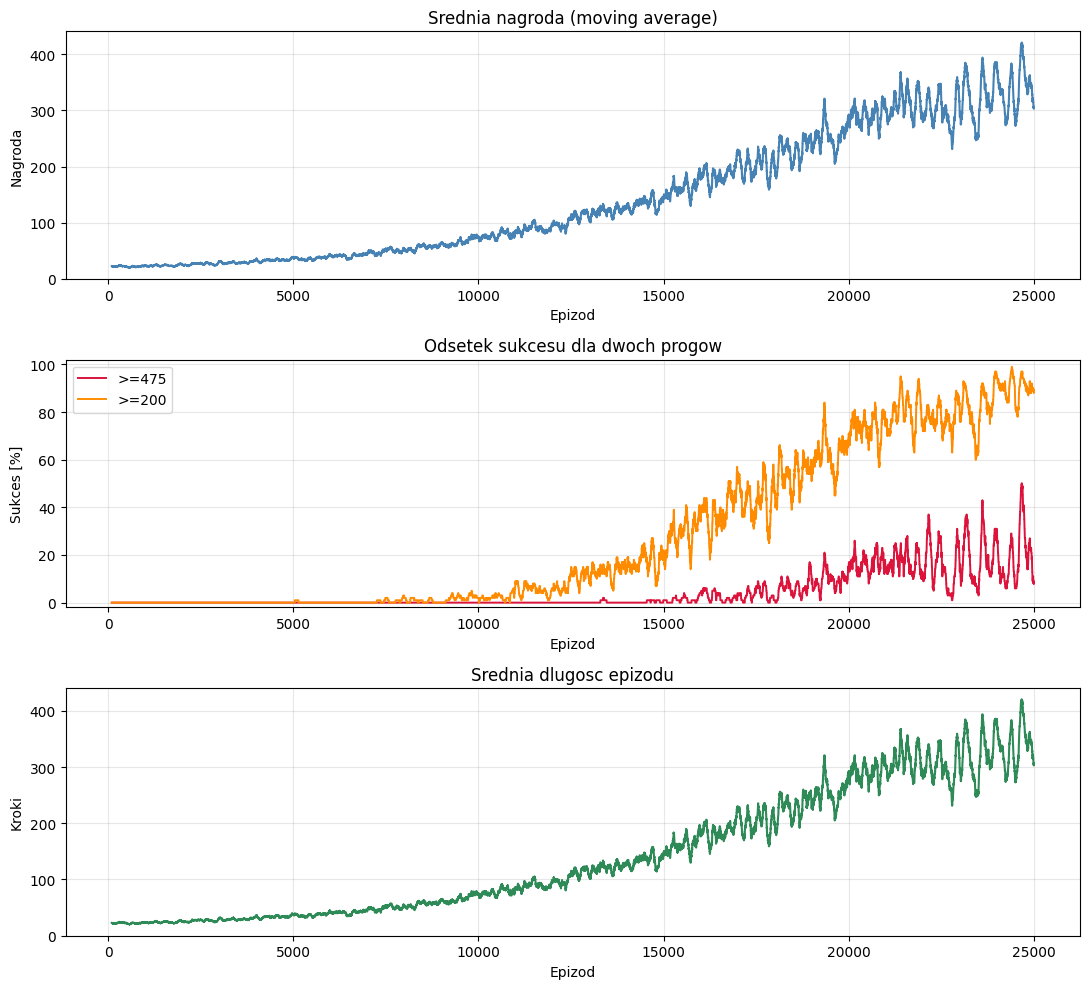

In [25]:
window = min(EVAL_WINDOW, len(episode_rewards))
x = np.arange(window, len(episode_rewards) + 1)

reward_smooth = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
strict_smooth = np.convolve(strict_success_history, np.ones(window) / window, mode="valid")
practical_smooth = np.convolve(practical_success_history, np.ones(window) / window, mode="valid")
length_smooth = np.convolve(episode_lengths, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(3, 1, figsize=(11, 10))

axes[0].plot(x, reward_smooth, color="steelblue", linewidth=1.5)
axes[0].set_title("Srednia nagroda (moving average)")
axes[0].set_xlabel("Epizod")
axes[0].set_ylabel("Nagroda")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, strict_smooth * 100, color="crimson", linewidth=1.4, label=f">={SUCCESS_THRESHOLD_STRICT}")
axes[1].plot(x, practical_smooth * 100, color="darkorange", linewidth=1.4, label=f">={SUCCESS_THRESHOLD_PRACTICAL}")
axes[1].set_title("Odsetek sukcesu dla dwoch progow")
axes[1].set_xlabel("Epizod")
axes[1].set_ylabel("Sukces [%]")
axes[1].set_ylim(-2, 102)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, length_smooth, color="seagreen", linewidth=1.5)
axes[2].set_title("Srednia dlugosc epizodu")
axes[2].set_xlabel("Epizod")
axes[2].set_ylabel("Kroki")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cartpole_learning_curve.png", dpi=150, bbox_inches="tight")
print("Wykres zapisany: cartpole_learning_curve.png")
plt.show()

In [26]:
eval_q = global_best_q

env_eval = gym.make(ENV_NAME)
eval_rewards = []
eval_discounted = []
eval_success_strict = []
eval_success_practical = []
rng_eval = np.random.default_rng(SEED + 1_000_000)

for ep in range(N_EVAL):
    state, _ = env_eval.reset(seed=100_000 + ep)
    state_idx = discretize_state(state)
    total_reward = 0.0
    total_discounted = 0.0
    discount = 1.0

    for _ in range(MAX_STEPS):
        action = greedy_action(eval_q, state_idx, rng_eval)
        next_state, reward, terminated, truncated, _ = env_eval.step(action)
        state_idx = discretize_state(next_state)
        total_reward += float(reward)
        total_discounted += discount * float(reward)
        discount *= GAMMA
        if terminated or truncated:
            break

    eval_rewards.append(total_reward)
    eval_discounted.append(total_discounted)
    eval_success_strict.append(1 if total_reward >= SUCCESS_THRESHOLD_STRICT else 0)
    eval_success_practical.append(1 if total_reward >= SUCCESS_THRESHOLD_PRACTICAL else 0)

env_eval.close()

print(f"Ewaluowany checkpoint z epizodu: {global_best_episode}")
print(f"Srednia nagroda (N={N_EVAL}): {np.mean(eval_rewards):.2f}")
print(f"Srednia nagroda zdyskontowana (gamma={GAMMA}): {np.mean(eval_discounted):.4f}")
print(f"Odsetek sukcesu >={SUCCESS_THRESHOLD_STRICT}: {np.mean(eval_success_strict) * 100:.1f}%")
print(f"Odsetek sukcesu >={SUCCESS_THRESHOLD_PRACTICAL}: {np.mean(eval_success_practical) * 100:.1f}%")
print(f"Min/Max nagroda: {np.min(eval_rewards):.1f} / {np.max(eval_rewards):.1f}")

Ewaluowany checkpoint z epizodu: 25000
Srednia nagroda (N=500): 319.38
Srednia nagroda zdyskontowana (gamma=0.99): 94.7180
Odsetek sukcesu >=475: 4.2%
Odsetek sukcesu >=200: 96.6%
Min/Max nagroda: 141.0 / 500.0


In [27]:
action_name = {0: "LEFT", 1: "RIGHT"}
env_demo = gym.make(ENV_NAME)
state, _ = env_demo.reset(seed=7)
state_idx = discretize_state(state)
rng_demo = np.random.default_rng(SEED + 2_000_000)

print("Pierwsze kroki trajektorii (max 20):")
for step in range(MAX_STEPS):
    action = greedy_action(eval_q, state_idx, rng_demo)
    next_state, reward, terminated, truncated, _ = env_demo.step(action)
    next_idx = discretize_state(next_state)

    if step < 20:
        x, x_dot, theta, theta_dot = next_state
        print(f"krok={step+1:2d} action={action_name[action]:5s} x={x:+.3f} x_dot={x_dot:+.3f} theta={theta:+.3f} theta_dot={theta_dot:+.3f}")

    state_idx = next_idx
    if terminated or truncated:
        print(f"Epizod zakonczony po {step+1} krokach.")
        break

env_demo.close()

Pierwsze kroki trajektorii (max 20):
krok= 1 action=RIGHT x=+0.013 x_dot=+0.234 theta=+0.027 theta_dot=-0.311
krok= 2 action=RIGHT x=+0.018 x_dot=+0.429 theta=+0.021 theta_dot=-0.595
krok= 3 action=LEFT  x=+0.027 x_dot=+0.234 theta=+0.009 theta_dot=-0.296
krok= 4 action=RIGHT x=+0.031 x_dot=+0.429 theta=+0.003 theta_dot=-0.586
krok= 5 action=LEFT  x=+0.040 x_dot=+0.234 theta=-0.009 theta_dot=-0.292
krok= 6 action=LEFT  x=+0.044 x_dot=+0.039 theta=-0.015 theta_dot=-0.003
krok= 7 action=LEFT  x=+0.045 x_dot=-0.156 theta=-0.015 theta_dot=+0.285
krok= 8 action=LEFT  x=+0.042 x_dot=-0.351 theta=-0.009 theta_dot=+0.573
krok= 9 action=RIGHT x=+0.035 x_dot=-0.156 theta=+0.003 theta_dot=+0.278
krok=10 action=RIGHT x=+0.032 x_dot=+0.039 theta=+0.008 theta_dot=-0.014
krok=11 action=RIGHT x=+0.033 x_dot=+0.234 theta=+0.008 theta_dot=-0.304
krok=12 action=RIGHT x=+0.037 x_dot=+0.429 theta=+0.002 theta_dot=-0.594
krok=13 action=LEFT  x=+0.046 x_dot=+0.234 theta=-0.010 theta_dot=-0.301
krok=14 action

In [28]:
np.save("q_table_cartpole_continuous.npy", eval_q)
np.savez(
    "cartpole_training_history.npz",
    rewards=np.asarray(episode_rewards, dtype=np.float32),
    lengths=np.asarray(episode_lengths, dtype=np.int32),
    strict_success=np.asarray(strict_success_history, dtype=np.int8),
    practical_success=np.asarray(practical_success_history, dtype=np.int8),
    final_epsilon=np.asarray([epsilon], dtype=np.float32),
    best_episode=np.asarray([global_best_episode], dtype=np.int32),
)

print("Zapisano: q_table_cartpole_continuous.npy (najlepszy checkpoint)")
print("Zapisano: cartpole_training_history.npz")
print(f"Ksztalt Q: {eval_q.shape}")
print(f"Liczba epizodow w historii: {len(episode_rewards)}")

Zapisano: q_table_cartpole_continuous.npy (najlepszy checkpoint)
Zapisano: cartpole_training_history.npz
Ksztalt Q: (8, 10, 16, 16, 2)
Liczba epizodow w historii: 25000
